# Exploration of hormonal receptor genes in Castaldi et al organoid dataset (only day 50)

[Reference paper](https://doi.org/10.1038/s41592-024-02555-5)

**NOTE**: Here I focus on on only day 50 subsetting already processed anndata with all samples --> I think it doesn't make so much sense but I keep it for completeness but better to look at the other script in this folder.

## 1. Environment Set Up

### 1.1 Library upload

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import igraph as ig
import matplotlib.pyplot as plt 
from scipy.sparse import csr_matrix, isspmatrix
from datetime import datetime
import sys
sys.path.append('../../')
import functions as fn

print(np.__version__)
print(pd.__version__)
print(sc.__version__)

1.23.5
2.0.0
1.9.3


In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100)

### 1.2 Starting computations: timestamp

In [3]:
print(datetime.now())

2026-01-08 13:25:19.007938


## 2. Read input files

### 2.1 adata loading

In [4]:
adata = sc.read('../../../../../Castaldi_multiplexingCBO/adataPaga.h5ad')

In [5]:
adata

AnnData object with n_obs × n_vars = 14913 × 3499
    obs: 'dataset', 'cellID', 'cellID_newName', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'stage', 'type', 'id_stage', 'cellID_newName_type', 'S_score', 'G2M_score', 'phase', 'leidenAnnotated', 'leiden_1.2', 'endpoint_GlutamatergicNeurons_late', 'endpoint_GlutamatergicNeurons_early', 'endpoint_MigratingNeurons', 'endpoint_OuterRadialGliaAstrocytes', 'endpoint_Interneurons', 'endpoint_Interneurons_GAD2', 'endpoint_CajalR_like', 'Exc_Lineage', 'endpoint_GlutamatergicNeurons_both'
    var: 'highly_variable', 'mean', 'std'
    uns: 'Exc_Lineage_colors', 'cellID_colors', 'cellID_newName_colors', 'cellID_newName_type_colors', 'cluster_colors', 'dataset_colors', 'diffmap_evals', 'draw_graph', 'leiden', 'leidenAnnotated_colors', 'leiden_1.2_colors', 'leiden_1.2_sizes', 'leide

In [6]:
print('Loaded Normalizes AnnData object: number of cells', adata.n_obs)
print('Loaded Normalizes AnnData object: number of genes', adata.n_vars)

# To see the columns of the metadata (information available for each cell)  
print('Available metadata for each cell: ', adata.obs.columns)

Loaded Normalizes AnnData object: number of cells 14913
Loaded Normalizes AnnData object: number of genes 3499
Available metadata for each cell:  Index(['dataset', 'cellID', 'cellID_newName', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       'stage', 'type', 'id_stage', 'cellID_newName_type', 'S_score',
       'G2M_score', 'phase', 'leidenAnnotated', 'leiden_1.2',
       'endpoint_GlutamatergicNeurons_late',
       'endpoint_GlutamatergicNeurons_early', 'endpoint_MigratingNeurons',
       'endpoint_OuterRadialGliaAstrocytes', 'endpoint_Interneurons',
       'endpoint_Interneurons_GAD2', 'endpoint_CajalR_like', 'Exc_Lineage',
       'endpoint_GlutamatergicNeurons_both'],
      dtype='object')


In [7]:
np.unique(adata.obs.values[:,14])

array(['downstream', 'upstream'], dtype=object)

### 2.2 Receptors signature loading

Loading of hormonal receptor gene signature.

In [8]:
signatures = '../../../../../DataDir/ExternalData/Receptors/ReceptorsComplete.txt'

In [9]:
signatures = '../../../../../DataDir/ExternalData/Receptors/ReceptorsComplete.txt'
sig = pd.read_csv(signatures, sep="\t", keep_default_na=False)  
print(sig.shape)
sig

(39, 2)


,GeneName,Signature
0,THRB,Thyroid
1,THRA,Thyroid
2,THRAP3,Thyroid
3,DIO1,Thyroid
4,DIO2,Thyroid
5,DIO3,Thyroid
6,SLC16A10,Thyroid
7,SLC16A2,Thyroid
8,SLC7A5,Thyroid
9,KLF9,Thyroid


In [10]:
genes = sig["GeneName"].values.tolist()

## 3. Visualizations

### 3.1 Counts from adata

In [11]:
adata.obsm

AxisArrays with keys: X_diffmap, X_draw_graph_fa, X_pca, X_umap

Subsetting adata to have only 'DownD50' and 'UpD50'

In [12]:
adata_sub = adata[adata.obs['dataset'].isin(['DownD50', 'UpD50'])].copy()

In [13]:
adata_sub.obs['dataset'].value_counts()

dataset
UpD50      2953
DownD50    2034
Name: count, dtype: int64

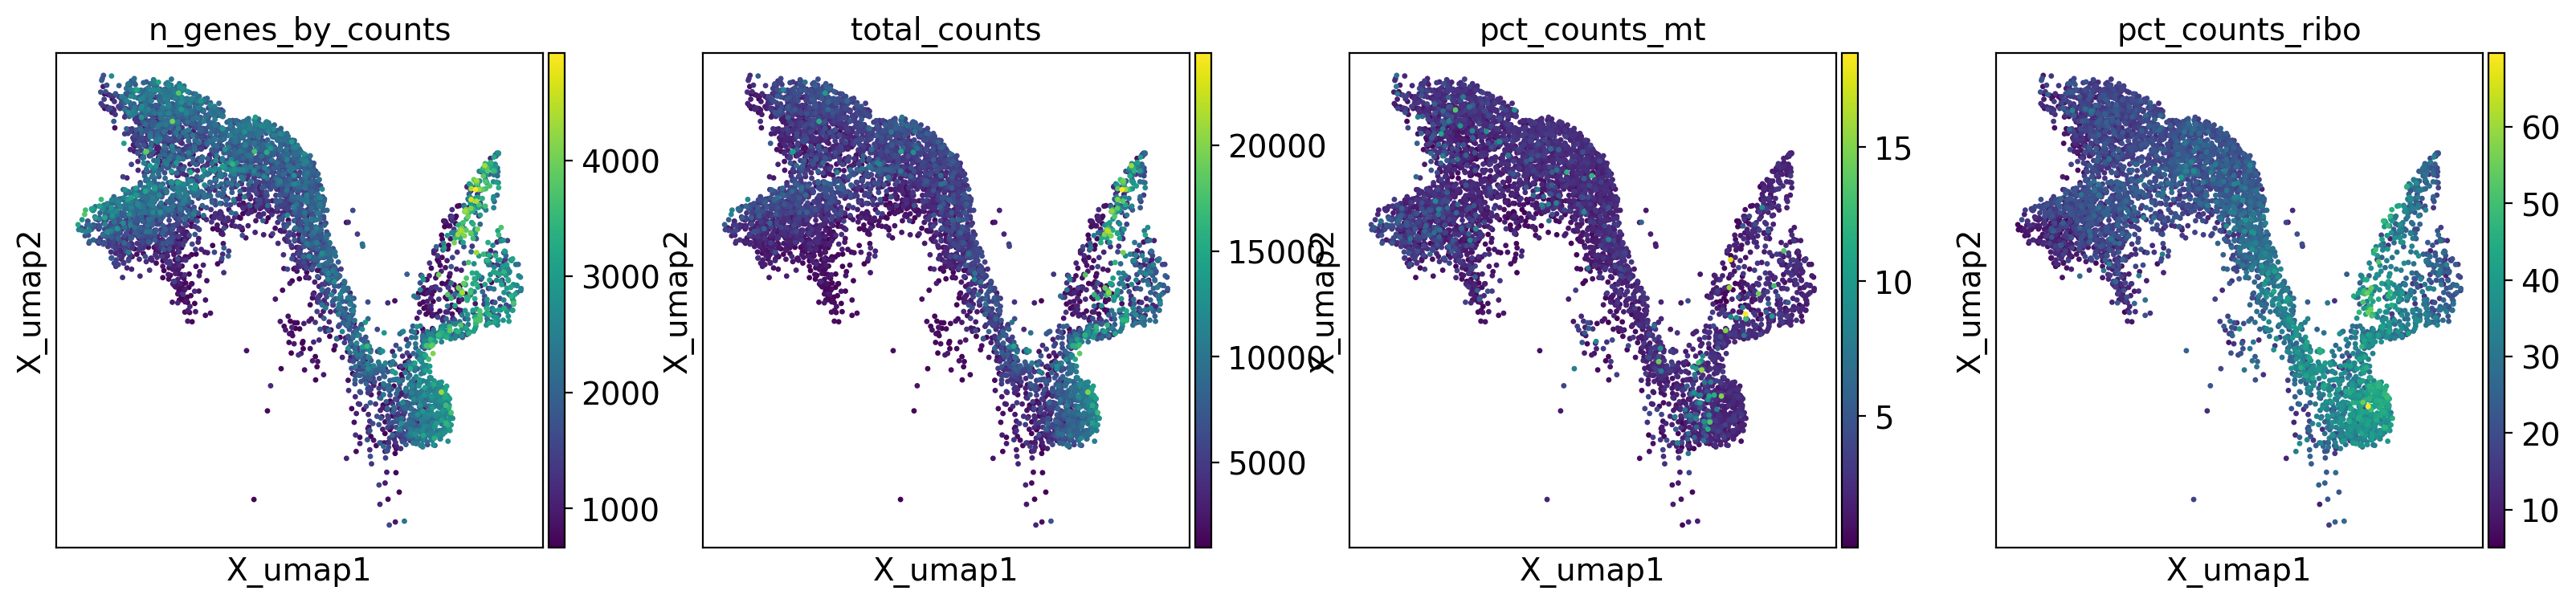

In [14]:
sc.pl.embedding(adata_sub, basis="X_umap", color=['n_genes_by_counts',"total_counts", 'pct_counts_mt', 'pct_counts_ribo'])

### 3.2 Clusters annotation

/usr/local/lib/python3.8/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


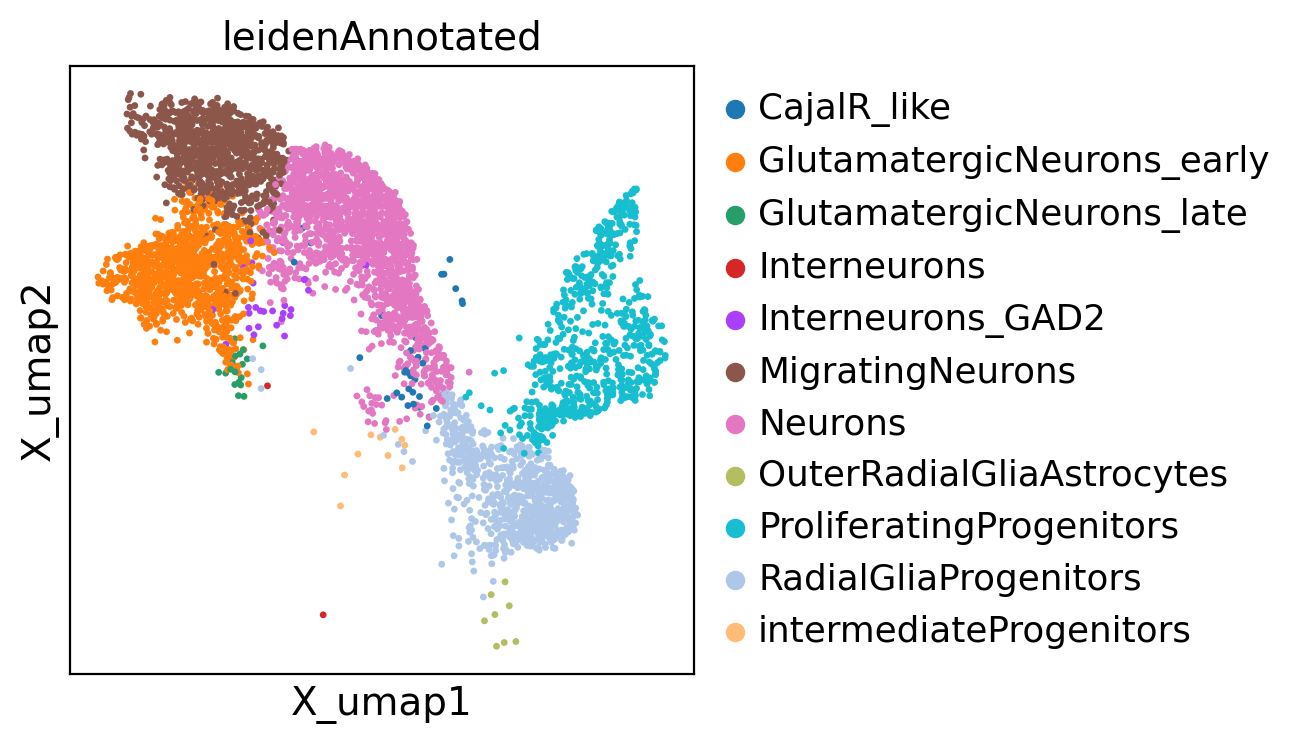

In [15]:
sc.pl.embedding(adata_sub,  basis="X_umap", color=['leidenAnnotated'], ncols=1)

/usr/local/lib/python3.8/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


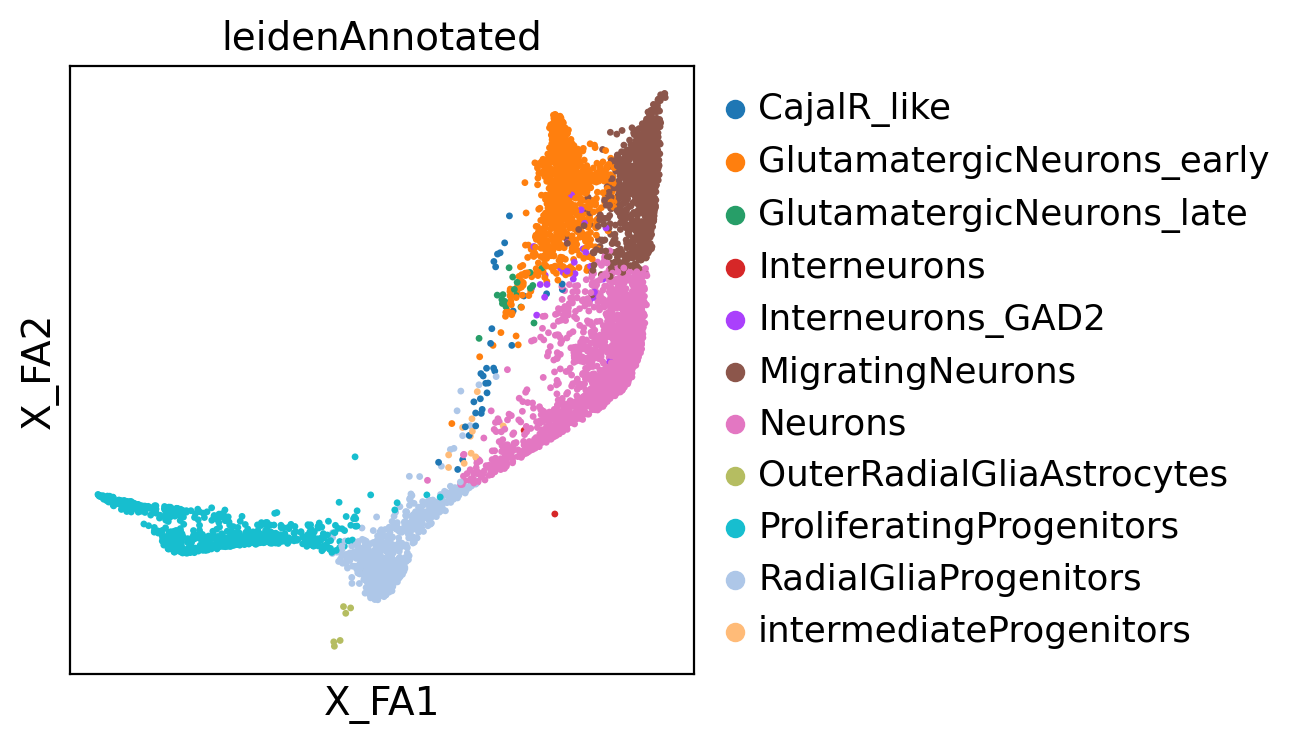

In [16]:
sc.pl.embedding(adata_sub,  basis="X_draw_graph_fa", color=['leidenAnnotated'], ncols=1)

### 3.3 Visualization of receptors on UMAP


The following marker genes are missing:  {'RXRA', 'DIO1', 'SLC16A2', 'NR1H3', 'GPER1', 'SLC16A10', 'ESRRA', 'ESR1', 'AHR', 'THRAP3', 'PTGER1', 'RARB', 'RXRB', 'THRSP', 'PTGER2', 'PPARD', 'PGR', 'KLF9', 'PTGER4', 'CYP19A1', 'PPARG', 'PPARA', 'RARA', 'VDR', 'ESR2', 'NR1H2', 'RBP4'}


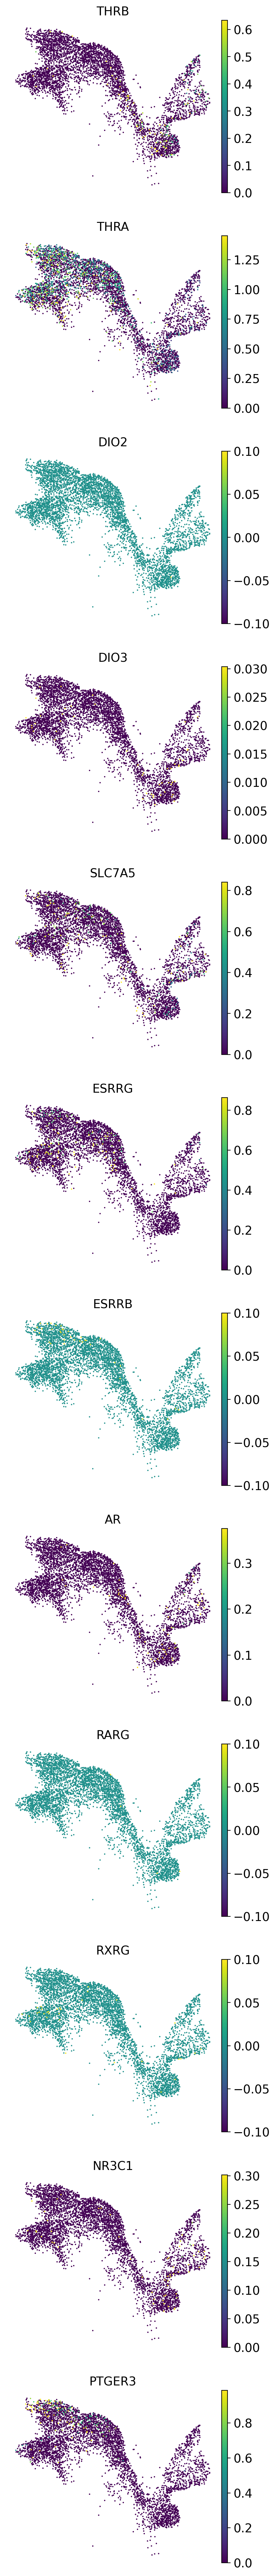

In [17]:
fn.CustomUmap(adata_sub, genes, embedding="X_umap") 


The following marker genes are missing:  {'RXRA', 'DIO1', 'SLC16A2', 'NR1H3', 'GPER1', 'SLC16A10', 'ESRRA', 'ESR1', 'AHR', 'THRAP3', 'PTGER1', 'RARB', 'RXRB', 'THRSP', 'PTGER2', 'PPARD', 'PGR', 'KLF9', 'PTGER4', 'CYP19A1', 'PPARG', 'PPARA', 'RARA', 'VDR', 'ESR2', 'NR1H2', 'RBP4'}


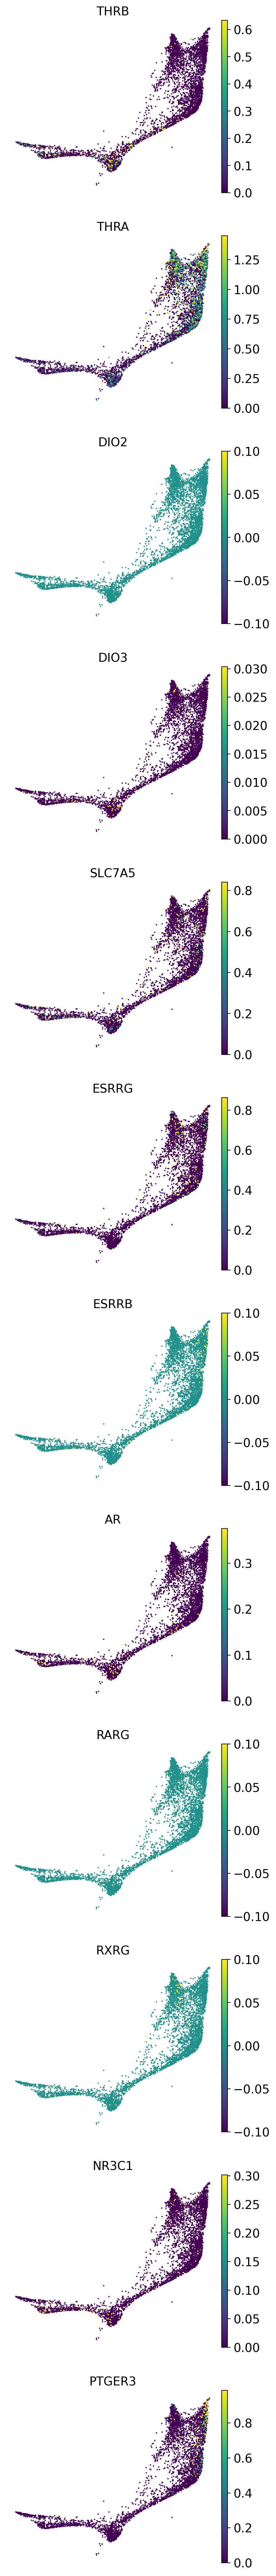

In [18]:
fn.CustomUmap(adata_sub, genes, embedding="X_draw_graph_fa") 

/usr/local/lib/python3.8/dist-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


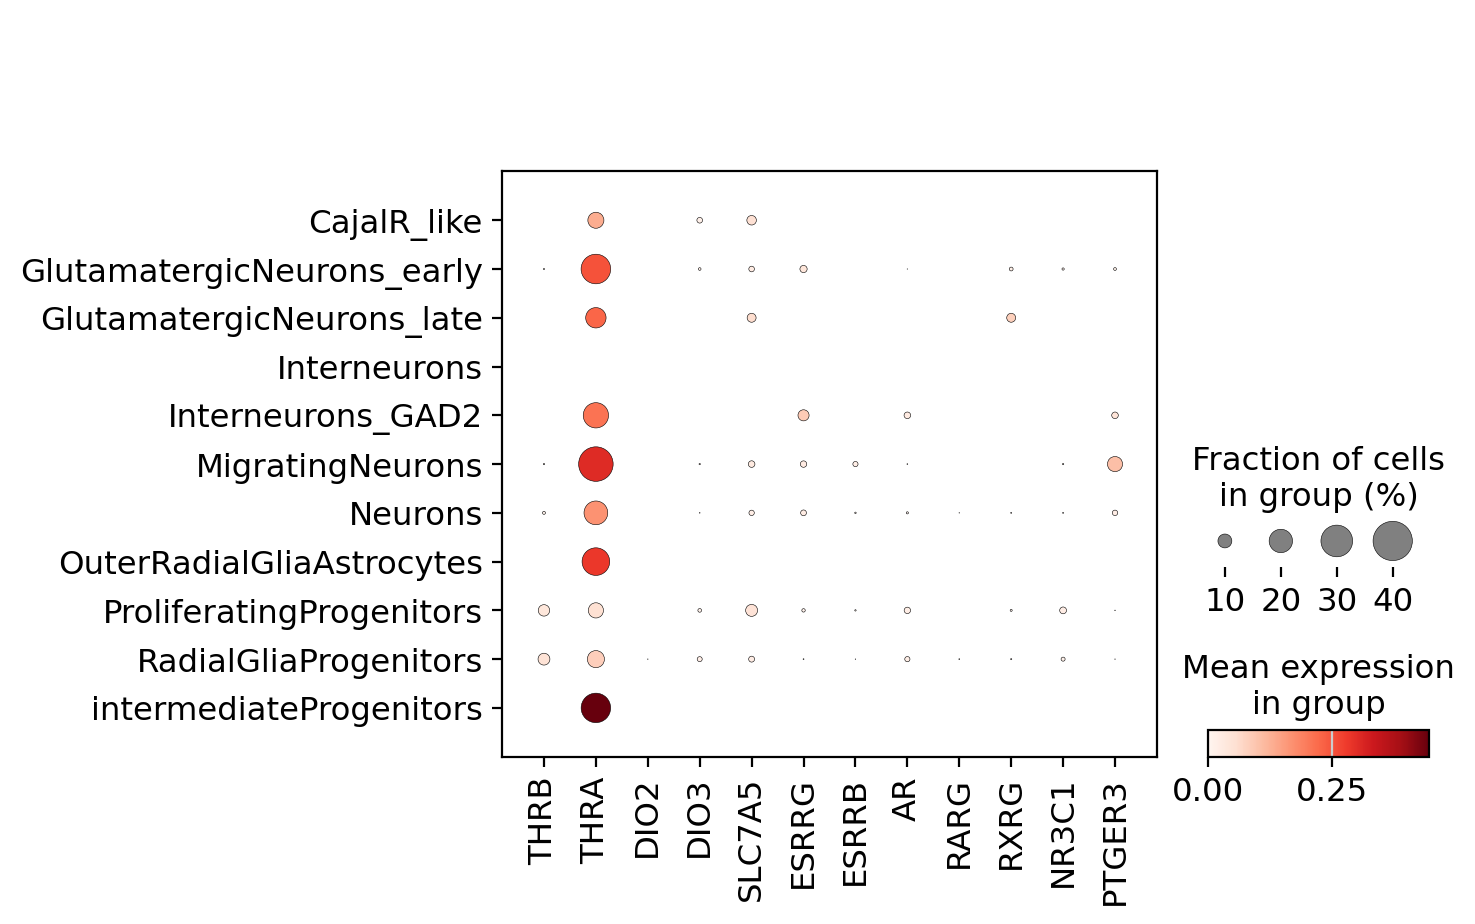

In [19]:
available_genes = [gene for gene in genes if gene in adata_sub.var_names]

if available_genes:
    sc.pl.dotplot(adata_sub, available_genes, groupby='leidenAnnotated')
else:
    print("None of the specified genes are found in adata.var_names.")

## 4. Save Notebooks

Adata is not saved, since no new computations have been performed. I just save the notebooks.

### 4.1 Timestamp finished computations

In [20]:
print(datetime.now())

2026-01-08 13:25:32.837813


### 4.2 Save python and html version of notebook

In [21]:
%%bash

# save also html and python versions for git
jupyter nbconvert ExplorationCastaldi-day50.ipynb --to="python" --output="ExplorationCastaldi-day50"
jupyter nbconvert ExplorationCastaldi-day50.ipynb --to="html" --output="ExplorationCastaldi-day50"

[NbConvertApp] Converting notebook ExplorationCastaldi-day50.ipynb to python
[NbConvertApp] Writing 3570 bytes to ExplorationCastaldi-day50.py
[NbConvertApp] Converting notebook ExplorationCastaldi-day50.ipynb to html
[NbConvertApp] Writing 7759694 bytes to ExplorationCastaldi-day50.html
